# Query Outage Data

This notebook queries and processes Austrian power plant outage data from the EEX Transparency API.

The Outage data is retrieved im form of Urgent Market Messages (UMMs). An UMM is created when ever there appears a new outage or information about a known outage is updated. Therefore a timeseries has to be constructed from the raw messages.

The code is structured in the following sections:

- **Imports and Settings**
- **Helper Functions**
- **Data Collection**
- **Initial Processing**
- **Outage Time Series Construction**
- **Plotting**
- **Final Processing**
- **Export**

In [ ]:
# =========================================================
# IMPORTS and Settings
# =========================================================

# ---------------------------------------------------------
# IMPORTS
# ---------------------------------------------------------

import heapq
import requests
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# SETTINGS
# ---------------------------------------------------------

BASE_URL = "https://api.eex-group.com/pub/transparency/non-availability-events/Power"

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
        "(KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36"
    ),
    "Accept": "application/json, text/plain, */*",
    "Origin": "https://www.eex-transparency.com",
    "Referer": "https://www.eex-transparency.com/",
}

TZ = "Europe/Vienna"
FREQ = "15min"
ROR_LABEL = "Hydro Run-of-river and poundage"

FROM_DATE = "2019-01-01"
TO_DATE = "2025-12-31"
COUNTRY = "AT"

In [2]:
# =========================================================
# HELPER FUNCTIONS
# =========================================================

# ---------------------------------------------------------
# API QUERY
# ---------------------------------------------------------

def fetch_events(country, date_from, date_to):
    params = {
        "country": country,
        "concernedDateFrom": date_from,
        "concernedDateTo": date_to,
    }

    session = requests.Session()
    session.headers.update(HEADERS)

    r = session.get(BASE_URL, params=params, timeout=60)
    r.raise_for_status()

    js = r.json()
    header = js["header"]
    rows = js["data"]

    return pd.DataFrame([dict(zip(header, row)) for row in rows])

# ---------------------------------------------------------
# MESSAGE VERSIONING
# ---------------------------------------------------------

def split_message_id(message_id):
    try:
        base, version = str(message_id).rsplit("_", 1)
        return base, int(version)
    except Exception:
        return str(message_id), 0

# ---------------------------------------------------------
# TIME SERIES UTILITIES
# ---------------------------------------------------------

def make_time_index(start="2019-01-01", end="2025-12-31 23:45", freq=FREQ, tz=TZ):
    return pd.date_range(
        pd.Timestamp(start, tz=tz),
        pd.Timestamp(end, tz=tz),
        freq=freq
    )


def latest_version_per_base(x):
    idx = x.groupby("base_id")["version"].idxmax()
    return x.loc[idx].copy()


def build_revision_history(x):
    hist = x.sort_values(["base_id", "modified", "version"]).copy()
    hist["known_from"] = hist["modified"]
    hist["known_to"] = hist.groupby("base_id")["modified"].shift(-1)
    hist["known_to"] = hist["known_to"].fillna(pd.Timestamp("2100-01-01", tz=TZ))
    return hist


# ---------------------------------------------------------
# SEGMENT BUILDING
# ---------------------------------------------------------

def build_unit_step_segments(events):
    """
    From event rows, build exact piecewise-constant outage segments per unit.

    Within a unit:
    - overlapping messages are resolved by max(effective_outage)
      = min available capacity if installed capacity is stable

    Returns a DataFrame with columns:
    unit_id, fuel_group, start, stop, outage
    """
    seg_rows = []

    if events.empty:
        return pd.DataFrame(columns=["unit_id", "fuel_group", "start", "stop", "outage"])

    for (unit_id, fuel_group), g in events.groupby(["unit_id", "fuel_group"], sort=False):
        starts = g[["eventStart", "effective_outage"]].copy()
        starts["delta"] = 1

        stops = g[["eventStop", "effective_outage"]].copy()
        stops.columns = ["eventStart", "effective_outage"]
        stops["delta"] = -1

        changes = pd.concat([starts, stops], ignore_index=True)
        changes = changes.rename(columns={"eventStart": "time", "effective_outage": "cap"})
        changes = changes.sort_values(["time", "delta"])  # stop(-1) before start(+1) at same ts

        active_counts = defaultdict(int)
        max_heap = []

        change_times = changes["time"].drop_duplicates().sort_values().to_list()

        grouped = {
            t: grp[["cap", "delta"]].to_records(index=False)
            for t, grp in changes.groupby("time", sort=True)
        }

        for i, t in enumerate(change_times[:-1]):
            # apply all changes at time t first
            for rec in grouped[t]:
                cap = float(rec.cap)
                delta = int(rec.delta)

                if delta == 1:
                    active_counts[cap] += 1
                    heapq.heappush(max_heap, -cap)
                else:
                    active_counts[cap] -= 1

            # clean heap
            while max_heap and active_counts[-max_heap[0]] <= 0:
                heapq.heappop(max_heap)

            next_t = change_times[i + 1]
            if next_t <= t:
                continue

            current_outage = -max_heap[0] if max_heap else 0.0
            if current_outage > 0:
                seg_rows.append((unit_id, fuel_group, t, next_t, current_outage))

        # last timestamp only updates state, but no interval after it -> no segment

    return pd.DataFrame(seg_rows, columns=["unit_id", "fuel_group", "start", "stop", "outage"])


def aggregate_unit_segments_to_global(unit_segments):
    """
    Sum unit step segments into exact global piecewise-constant segments.
    Output columns:
    start, stop, outage_ror, outage_other, outage_total
    """
    if unit_segments.empty:
        return pd.DataFrame(columns=["start", "stop", "outage_ror", "outage_other", "outage_total"])

    deltas = defaultdict(lambda: {"ror": 0.0, "other": 0.0})

    for row in unit_segments.itertuples():
        fg = row.fuel_group
        deltas[row.start][fg] += row.outage
        deltas[row.stop][fg]  -= row.outage

    times = sorted(deltas.keys())
    rows = []

    cur_ror = 0.0
    cur_other = 0.0

    for i, t in enumerate(times[:-1]):
        cur_ror += deltas[t]["ror"]
        cur_other += deltas[t]["other"]

        next_t = times[i + 1]
        if next_t <= t:
            continue

        rows.append((
            t,
            next_t,
            cur_ror,
            cur_other,
            cur_ror + cur_other
        ))

    return pd.DataFrame(
        rows,
        columns=["start", "stop", "outage_ror", "outage_other", "outage_total"]
    )


# ---------------------------------------------------------
# GRID SAMPLING
# ---------------------------------------------------------

def sample_global_segments_to_grid(global_segments, time_index):
    """
    Sample exact step-function global segments on the QH delivery grid.
    Used for ground truth.
    """
    out = pd.DataFrame(index=time_index, columns=["outage_ror", "outage_other", "outage_total"], dtype=float)
    out[:] = 0.0

    if global_segments.empty:
        return out

    starts = global_segments["start"].to_numpy()
    stops  = global_segments["stop"].to_numpy()

    grid = time_index.to_numpy()

    idx = np.searchsorted(starts, grid, side="right") - 1
    valid = (idx >= 0)
    valid &= (grid < stops[np.clip(idx, 0, len(stops)-1)])

    for col in ["outage_ror", "outage_other", "outage_total"]:
        vals = global_segments[col].to_numpy()
        arr = np.zeros(len(grid), dtype=float)
        arr[valid] = vals[idx[valid]]
        out[col] = arr

    return out


# ---------------------------------------------------------
# EXACT WINDOW AVERAGING
# ---------------------------------------------------------

def _prepare_integral(global_segments, value_col):
    if global_segments.empty:
        return None

    boundaries = pd.Index(
        list(global_segments["start"]) + [global_segments["stop"].iloc[-1]]
    ).to_numpy(dtype="datetime64[ns]")

    values = global_segments[value_col].to_numpy(dtype=float)

    dt_hours = ((boundaries[1:] - boundaries[:-1]) / np.timedelta64(1, "h")).astype(float)

    cum_area = np.zeros(len(boundaries), dtype=float)
    cum_area[1:] = np.cumsum(values * dt_hours)

    return {"boundaries": boundaries, "values": values, "cum_area": cum_area}


def _integral_at(prep, t_values):
    boundaries = prep["boundaries"]
    values = prep["values"]
    cum_area = prep["cum_area"]

    t_values = pd.DatetimeIndex(t_values).to_numpy(dtype="datetime64[ns]")
    idx = np.searchsorted(boundaries, t_values, side="right") - 1

    res = np.zeros(len(t_values), dtype=float)

    mask_mid = (idx >= 0) & (idx < len(values))
    if mask_mid.any():
        j = idx[mask_mid]
        dt_hours = ((t_values[mask_mid] - boundaries[j]) / np.timedelta64(1, "h")).astype(float)
        res[mask_mid] = cum_area[j] + values[j] * dt_hours

    mask_after = idx >= len(values)
    if mask_after.any():
        res[mask_after] = cum_area[-1]

    return res


def exact_window_average_from_global_segments(global_segments, time_index, window_hours):
    out = pd.DataFrame(index=time_index, columns=["outage_ror", "outage_other", "outage_total"], dtype=float)
    out[:] = 0.0

    if global_segments.empty:
        return out

    tau = time_index.to_numpy(dtype="datetime64[ns]")
    tau_lag = (time_index - pd.Timedelta(hours=window_hours)).to_numpy(dtype="datetime64[ns]")

    for col in ["outage_ror", "outage_other", "outage_total"]:
        prep = _prepare_integral(global_segments, col)
        area_tau = _integral_at(prep, tau)
        area_lag = _integral_at(prep, tau_lag)
        out[col] = (area_tau - area_lag) / float(window_hours)

    return out

In [3]:
# =========================================================
# DATA COLLECTION
# =========================================================

df_raw = fetch_events(
    country=COUNTRY,
    date_from=FROM_DATE,
    date_to=TO_DATE,
)

print(df_raw.shape)
df_raw.head(3)

(124690, 23)


,unavailabilityType,eventType,companyName,companyID,facilityName,unitName,eIC,aCE,shareholders,biddingZone,...,installedCapacity,availableCapacity,nonAvailableCapacity,unavailabilityReason,remarks,eventStatus,messageID,modified,unitMeasure,capacityIntervals
0,Planned,Production unavailability,VERBUND AG,VerbundAG,Ybbs-Persenbeug,Ybbs-Persenbeug MS 4,14W-BYPKWTU4---C,A0000793C.AT,None,10YAT-APG------L,...,32.3,0.0,32.3,Maintenance,None,Active,BYP-MS4-000000000073#7810_015,2026-05-06T14:08:36.000Z,MW,[]
1,Planned,Production unavailability,VERBUND AG,VerbundAG,Kraftwerk Jochenstein AT,Jochenstein MS 3,14W-GJO-KW-TU3-K,A0000793C.AT,None,10YAT-APG------L,...,26.4,0.0,26.4,Maintenance,None,Active,GJO-MS3-000000013204#7938_006,2026-04-30T13:07:48.000Z,MW,[]
2,Unplanned,Other unavailability,VERBUND AG,VerbundAG,Mooserboden,Mooserboden,14W-MOBO-PS----G,A0000793C.AT,None,10YAT-APG------L,...,1152.8,512.8,80.0,Outage,None,Active,TKO-P2-0000000019157#2492_005,2026-04-30T06:12:18.000Z,MW,[]


In [ ]:
dfb# =========================================================
# INITIAL PROCESSING
# =========================================================

# ---------------------------------------------------------
# FILTER RELEVANT OUTAGE EVENTS
# ---------------------------------------------------------

df = df_raw.copy()

df = df[
    (df["unavailabilityType"] == "Unplanned") &
    (df["eventType"] == "Production unavailability")
]

# ---------------------------------------------------------
# PARSE IDENTIFIERS AND TIMESTAMPS
# ---------------------------------------------------------

df["base_id"] = df["messageID"].map(lambda x: split_message_id(x)[0])
df["version"] = df["messageID"].map(lambda x: split_message_id(x)[1])

df["eventStart"] = pd.to_datetime(df["eventStart"], utc=True, errors="coerce").dt.tz_convert(TZ)
df["eventStop"] = pd.to_datetime(df["eventStop"], utc=True, errors="coerce").dt.tz_convert(TZ)
df["modified"] = pd.to_datetime(df["modified"], utc=True, errors="coerce").dt.tz_convert(TZ)

# ---------------------------------------------------------
# PREPARE CAPACITY VALUES
# ---------------------------------------------------------

for c in ["installedCapacity", "availableCapacity", "nonAvailableCapacity"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["unit_id"] = (
    df["facilityName"].fillna("").astype(str) + "|" +
    df["unitName"].fillna("").astype(str) + "|" +
    df["eIC"].fillna("").astype(str)
)

df["fuel_group"] = np.where(df["fuelType"].eq(ROR_LABEL), "ror", "other")

# prefer installed - available, fallback to nonAvailableCapacity
df["effective_outage"] = np.where(
    df["installedCapacity"].notna() & df["availableCapacity"].notna(),
    df["installedCapacity"] - df["availableCapacity"],
    df["nonAvailableCapacity"]
)

df["effective_outage"] = pd.to_numeric(df["effective_outage"], errors="coerce").fillna(0.0)
df["effective_outage"] = df["effective_outage"].clip(lower=0.0)

# ---------------------------------------------------------
# KEEP USABLE ROWS
# ---------------------------------------------------------

df = df.dropna(subset=["eventStart", "eventStop", "modified"]).copy()
df = df[df["eventStop"] > df["eventStart"]].copy()

print(df.shape)
df[[
    "messageID", "base_id", "version", "eventStatus",
    "eventStart", "eventStop", "modified",
    "installedCapacity", "availableCapacity", "nonAvailableCapacity",
    "effective_outage", "fuel_group", "unit_id"
]].head(3)


(37917, 28)


,messageID,base_id,version,eventStatus,eventStart,eventStop,modified,installedCapacity,availableCapacity,nonAvailableCapacity,effective_outage,fuel_group,unit_id
3,TKO-MS2-000000019155#7927_005,TKO-MS2-000000019155#7927,5,Active,2025-11-05 17:30:00+01:00,2027-03-15 17:00:00+01:00,2026-04-30 08:11:48+02:00,80.0,0.0,80.0,80.0,other,Kaprun-Oberstufe|Kaprun-Oberstufe TU 2|14W-TKO...
5,TKO-MS1-000000019156#7926_005,TKO-MS1-000000019156#7926,5,Active,2025-11-05 17:30:00+01:00,2027-03-15 17:00:00+01:00,2026-04-30 08:10:48+02:00,80.0,0.0,80.0,80.0,other,Kaprun-Oberstufe|Kaprun-Oberstufe TU 1|14W-TKO...
15,DRP-MS1-000000019467#7932_017,DRP-MS1-000000019467#7932,17,Active,2025-11-08 05:15:00+01:00,2026-03-26 16:11:00+01:00,2026-03-26 16:11:57+01:00,215.0,0.0,215.0,215.0,other,Reisseck 2|Reisseck 2 TU 1|14W-DRPKWTU1---6


In [5]:
# =========================================================
# OUTAGE TIME SERIES CONSTRUCTION
# =========================================================

time_index = make_time_index("2019-01-01", "2025-12-31 23:45")

# ---------------------------------------------------------
# GROUND TRUTH
# ---------------------------------------------------------

latest = latest_version_per_base(df)

truth_events = latest[
    (latest["eventStatus"] == "Active") &
    (latest["effective_outage"] > 0)
].copy()

truth_unit_segments = build_unit_step_segments(truth_events)
truth_global_segments = aggregate_unit_segments_to_global(truth_unit_segments)
ts_true_qh = sample_global_segments_to_grid(truth_global_segments, time_index)

# ---------------------------------------------------------
# BELIEF STATE
# ---------------------------------------------------------

hist = build_revision_history(df)

belief_events = hist[
    (hist["eventStatus"] == "Active") &
    (hist["effective_outage"] > 0)
].copy()

belief_events["belief_from"] = belief_events[["eventStart", "known_from"]].max(axis=1)
belief_events["belief_to"] = belief_events[["eventStop", "known_to"]].min(axis=1)

belief_events = belief_events[belief_events["belief_to"] > belief_events["belief_from"]].copy()

belief_events_for_seg = belief_events.copy()
belief_events_for_seg["eventStart"] = belief_events_for_seg["belief_from"]
belief_events_for_seg["eventStop"] = belief_events_for_seg["belief_to"]

belief_unit_segments = build_unit_step_segments(belief_events_for_seg)
belief_global_segments = aggregate_unit_segments_to_global(belief_unit_segments)

# optional: sampled belief state on QH grid, just for inspection
ts_belief_qh = sample_global_segments_to_grid(belief_global_segments, time_index)

# ---------------------------------------------------------
# ID1 AND ID3 KNOWLEDGE WINDOWS
# ---------------------------------------------------------

ts_id1_qh = exact_window_average_from_global_segments(
    belief_global_segments,
    time_index,
    window_hours=1
)

ts_id3_qh = exact_window_average_from_global_segments(
    belief_global_segments,
    time_index,
    window_hours=3
)

print("truth events:", len(truth_events))
print("belief events:", len(belief_events))
print("truth unit segments :", len(truth_unit_segments))
print("belief unit segments:", len(belief_unit_segments))
print("truth global segments :", len(truth_global_segments))
print("belief global segments:", len(belief_global_segments))
print()
print("ts_true_qh shape  :", ts_true_qh.shape)
print("ts_id1_qh shape   :", ts_id1_qh.shape)
print("ts_id3_qh shape   :", ts_id3_qh.shape)

display(ts_true_qh.head())
display(ts_id1_qh.head())
display(ts_id3_qh.head())

truth events: 11816
belief events: 18003
truth unit segments : 11622
belief unit segments: 18122
truth global segments : 17579
belief global segments: 26310

ts_true_qh shape  : (245472, 3)
ts_id1_qh shape   : (245472, 3)
ts_id3_qh shape   : (245472, 3)


,outage_ror,outage_other,outage_total
2019-01-01 00:00:00+01:00,0.0,270.0,270.0
2019-01-01 00:15:00+01:00,0.0,270.0,270.0
2019-01-01 00:30:00+01:00,0.0,270.0,270.0
2019-01-01 00:45:00+01:00,0.0,270.0,270.0
2019-01-01 01:00:00+01:00,0.0,270.0,270.0


,outage_ror,outage_other,outage_total
2019-01-01 00:00:00+01:00,0.0,270.0,270.0
2019-01-01 00:15:00+01:00,0.0,270.0,270.0
2019-01-01 00:30:00+01:00,0.0,270.0,270.0
2019-01-01 00:45:00+01:00,0.0,270.0,270.0
2019-01-01 01:00:00+01:00,0.0,270.0,270.0


,outage_ror,outage_other,outage_total
2019-01-01 00:00:00+01:00,0.0,270.0,270.0
2019-01-01 00:15:00+01:00,0.0,270.0,270.0
2019-01-01 00:30:00+01:00,0.0,270.0,270.0
2019-01-01 00:45:00+01:00,0.0,270.0,270.0
2019-01-01 01:00:00+01:00,0.0,270.0,270.0


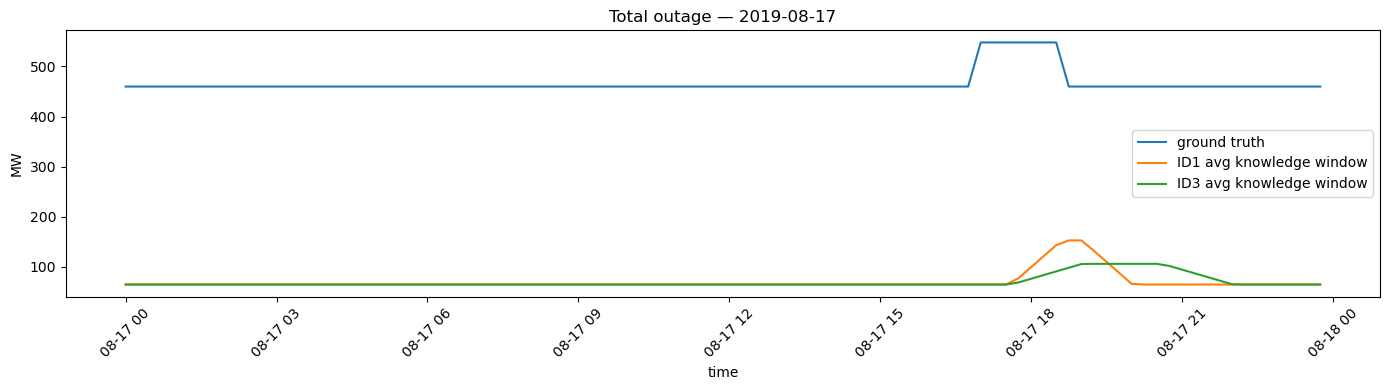

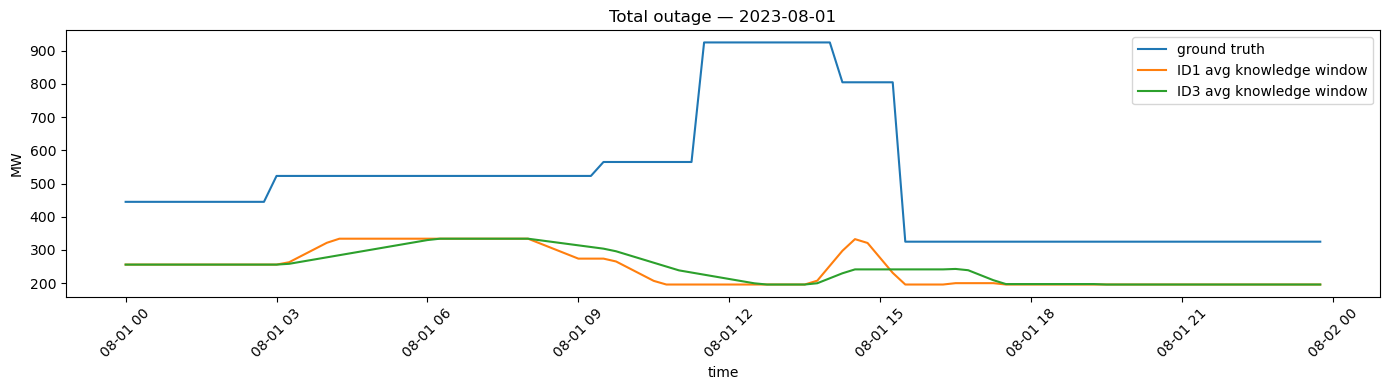

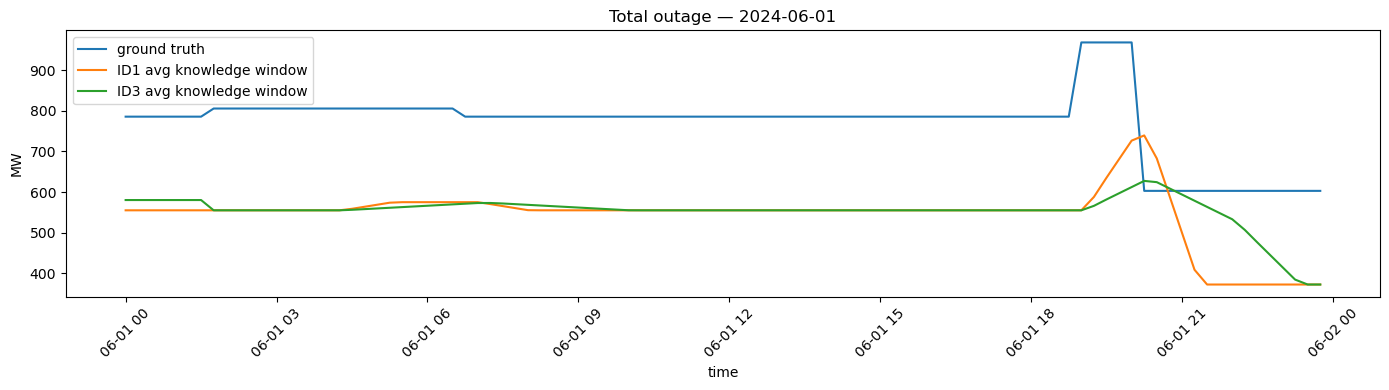

In [9]:
# =========================================================
# PLOTTING
# =========================================================

rng = np.random.default_rng(42)

all_days = pd.Index(ts_true_qh.index.normalize().unique())
sample_n = min(3, len(all_days))
sampled_days = pd.to_datetime(rng.choice(all_days, size=sample_n, replace=False))
sampled_days = sampled_days.sort_values()

for day in sampled_days:
    day_end = day + pd.Timedelta(days=1)

    s_true = ts_true_qh.loc[day:day_end - pd.Timedelta(minutes=15), "outage_total"]
    s_id1 = ts_id1_qh.loc[day:day_end - pd.Timedelta(minutes=15), "outage_total"]
    s_id3 = ts_id3_qh.loc[day:day_end - pd.Timedelta(minutes=15), "outage_total"]

    # Quick visual sanity check of the processed outage series
    plt.figure(figsize=(14, 4))
    plt.plot(s_true.index, s_true.values, label="ground truth")
    plt.plot(s_id1.index, s_id1.values, label="ID1 avg knowledge window")
    plt.plot(s_id3.index, s_id3.values, label="ID3 avg knowledge window")

    plt.title(f"Total outage — {day.date()}")
    plt.xlabel("time")
    plt.ylabel("MW")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:
# =========================================================
# FINAL PROCESSING
# =========================================================

# ---------------------------------------------------------
# RENAME COLUMNS
# ---------------------------------------------------------

ts_true = ts_true_qh.rename(columns={
    "outage_ror": "outage_ror_true",
    "outage_other": "outage_other_true",
    "outage_total": "outage_total_true",
})

ts_id1 = ts_id1_qh.rename(columns={
    "outage_ror": "outage_ror_id1",
    "outage_other": "outage_other_id1",
    "outage_total": "outage_total_id1",
})

ts_id3 = ts_id3_qh.rename(columns={
    "outage_ror": "outage_ror_id3",
    "outage_other": "outage_other_id3",
    "outage_total": "outage_total_id3",
})

# ---------------------------------------------------------
# COMBINE QH TIME SERIES
# ---------------------------------------------------------

ts_qh = pd.concat([ts_true, ts_id1, ts_id3], axis=1)
ts_qh = ts_qh.sort_index()
ts_qh.index.name = "datetime"

print("QH shape:", ts_qh.shape)
display(ts_qh.head())

# ---------------------------------------------------------
# CREATE HOURLY VERSION
# ---------------------------------------------------------

ts_h = ts_qh.resample("1h").mean()
ts_h.index.name = "datetime"

print("H shape:", ts_h.shape)
display(ts_h.head())

QH shape: (245472, 9)


,outage_ror_true,outage_other_true,outage_total_true,outage_ror_id1,outage_other_id1,outage_total_id1,outage_ror_id3,outage_other_id3,outage_total_id3
datetime,,,,,,,,,
2019-01-01 00:00:00+01:00,0.0,270.0,270.0,0.0,270.0,270.0,0.0,270.0,270.0
2019-01-01 00:15:00+01:00,0.0,270.0,270.0,0.0,270.0,270.0,0.0,270.0,270.0
2019-01-01 00:30:00+01:00,0.0,270.0,270.0,0.0,270.0,270.0,0.0,270.0,270.0
2019-01-01 00:45:00+01:00,0.0,270.0,270.0,0.0,270.0,270.0,0.0,270.0,270.0
2019-01-01 01:00:00+01:00,0.0,270.0,270.0,0.0,270.0,270.0,0.0,270.0,270.0


H shape: (61368, 9)


,outage_ror_true,outage_other_true,outage_total_true,outage_ror_id1,outage_other_id1,outage_total_id1,outage_ror_id3,outage_other_id3,outage_total_id3
datetime,,,,,,,,,
2019-01-01 00:00:00+01:00,0.0,270.0,270.0,0.0,270.0,270.0,0.0,270.0,270.0
2019-01-01 01:00:00+01:00,0.0,270.0,270.0,0.0,270.0,270.0,0.0,270.0,270.0
2019-01-01 02:00:00+01:00,0.0,270.0,270.0,0.0,270.0,270.0,0.0,270.0,270.0
2019-01-01 03:00:00+01:00,0.0,270.0,270.0,0.0,270.0,270.0,0.0,270.0,270.0
2019-01-01 04:00:00+01:00,0.0,270.0,270.0,0.0,270.0,270.0,0.0,270.0,270.0


In [ ]:
# =========================================================
# EXPORT
# =========================================================

ts_h.to_csv("../data/outage_data_h.csv")
ts_qh.to_csv("../data/outage_data_qh.csv")